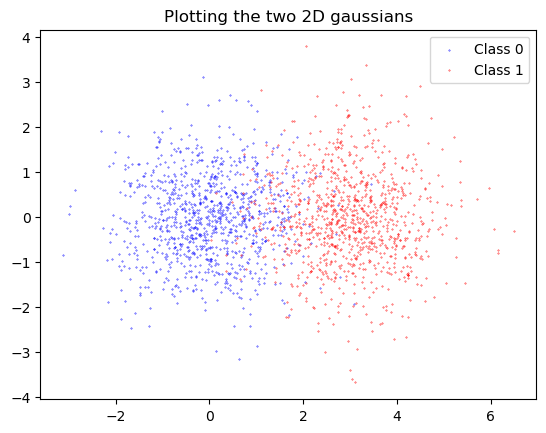

In [21]:
#Question number 1 from Homework 1
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt
mean1 = [0,0]
mean2 = [3,0]
covariance = [[1,0],[0,1]]
N_value = 1000
x_values1, y_values1 = np.random.multivariate_normal(mean1, covariance, N_value).T
x_values2, y_values2 = np.random.multivariate_normal(mean2, covariance, N_value).T

fig, ax = plt.subplots()

plt.scatter(x_values1, y_values1, c='b', label='Class 0', s=0.1)
plt.scatter(x_values2, y_values2, c='r', label='Class 1', s=0.1)
plt.title('Plotting the two 2D gaussians')
plt.legend()
plt.show()

In [65]:
#Question Number 2 for Homework 4
#Need to reformat the data to match what we need it to be.
testx1 = x_values1[0:250]
testy1 = y_values1[0:250]
testx2 = x_values2[0:250]
testy2 = y_values2[0:250]
classarray = np.concatenate( (np.zeros(len(x_values1)), np.ones(len(x_values2)))).astype(int)
datalist = []
for i in np.arange(len(x_values1)):
    datalist.append(np.array([x_values1[i],y_values1[i]]))

for j in np.arange(len(x_values2)):
    datalist.append(np.array([x_values2[j],y_values2[j]]))
    
dataarray = np.array(datalist)
#Get test data. I took a fifth of the data to be my test data.
test_data = dataarray
test_class = classarray
#Fit test data.
clf_lr = LogisticRegression()
clf_lr.fit(test_data, test_class)

print(f"Weights w = {clf_lr.coef_[0]}")
print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
print(f"Accuracy = {clf_lr.score(test_data, test_class):.2%}")



Weights w = [3.01377868 0.00340078]
Bias    b = -4.432
Accuracy = 93.05%


In [54]:
def plot_decision_boundary(clf, X, y, ax=None, title='', feature_names=None, class_names=None):
    """Plot 2D decision boundary with probability shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # create mesh
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    # predict probabilities on mesh
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    # plot
    cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    
    colors = ['tab:blue', 'tab:green']
    for c in np.unique(y):
        sel = y == c
        label = class_names[c] if class_names is not None else f'class {c}'
        ax.scatter(X[sel, 0], X[sel, 1], c=colors[c], edgecolors='k', label=label, alpha=0.8)
    
    if feature_names is not None:
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
    ax.legend()
    ax.set_title(title)
    plt.colorbar(cf, ax=ax, label='P(class 1)')
    return ax

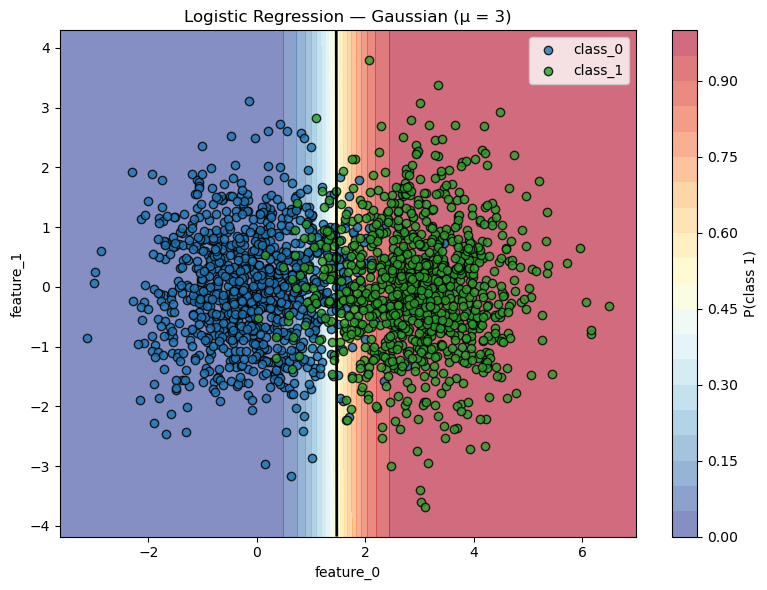

In [66]:
from sklearn.utils import Bunch

my_dataset = Bunch(
    data=test_data,
    target=test_class,
    target_names=np.array(['class_0','class_1']),
    feature_names=['feature_0','feature_1'],
    DESCR="2D Gaussian dataset"
    )

plot_decision_boundary(
    clf_lr, test_data, test_class,
    title='Logistic Regression — Gaussian (μ = 3)',
    feature_names= my_dataset.feature_names[:2],
    class_names=list(my_dataset.target_names[:2])
    )
plt.tight_layout()
plt.show()

In [76]:
#Problem three for Homework four.
#Now plot the μ values being 2, 1, 0.5
#But first for μ = 3, we need the false positive and false negative rates. 
from sklearn.metrics import confusion_matrix
class_pred = clf_lr.predict(test_data)
cm = confusion_matrix(test_class, class_pred)
print('For μ = 3')
print(cm)
print('False Positive rate',cm[0,1]/np.sum(cm))
print('False Negative rate',cm[1,0]/np.sum(cm))
print(f"Accuracy = {clf_lr.score(test_data, test_class):.2%}")
clf_lr.score(test_data, test_class)
accuracy_array = np.zeros(4)
accuracy_array[0] = clf_lr.score(test_data, test_class)
mean_array = np.array([3,2,1,0.5])

For μ = 3
[[931  69]
 [ 70 930]]
False Positive rate 0.0345
False Negative rate 0.035
Accuracy = 93.05%


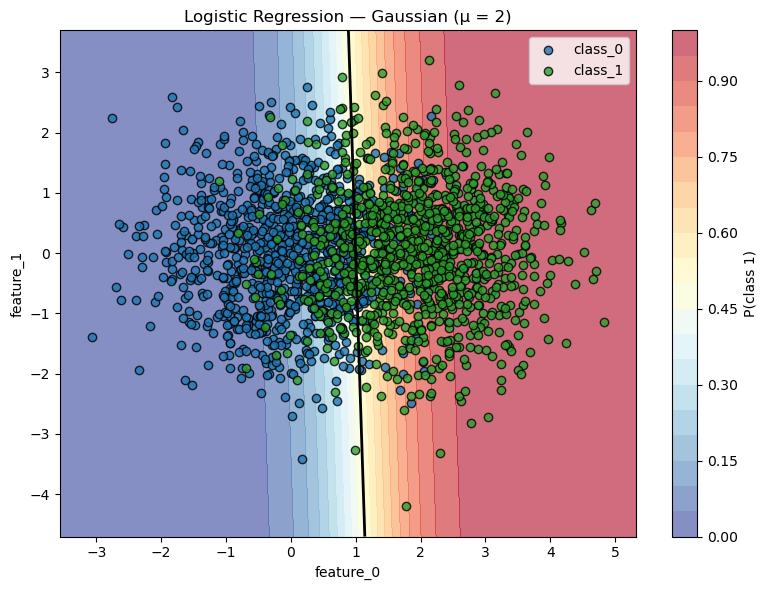

For μ = 2
[[848 152]
 [161 839]]
False Positive rate 0.076
False Negative rate 0.0805
Accuracy = 84.35%


In [82]:
#μ = 2

mean3 = [2,0]
N_value = 1000
x_values3, y_values3 = np.random.multivariate_normal(mean1, covariance, N_value).T
x_values4, y_values4 = np.random.multivariate_normal(mean3, covariance, N_value).T

classarray1 = np.concatenate( (np.zeros(len(x_values3)), np.ones(len(x_values4)))).astype(int)
datalist1 = []
for i in np.arange(len(x_values3)):
    datalist1.append(np.array([x_values3[i],y_values3[i]]))

for j in np.arange(len(x_values4)):
    datalist1.append(np.array([x_values4[j],y_values4[j]]))
    
dataarray1 = np.array(datalist1)
#Get test data. I took a fifth of the data to be my test data.
test_data1 = dataarray1
test_class1 = classarray1
#Fit test data.
clf_lr1 = LogisticRegression()
clf_lr1.fit(test_data1, test_class1)

#print(f"Weights w = {clf_lr.coef_[0]}")
#print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
#print(f"Accuracy = {clf_lr1.score(test_data1, test_class1):.2%}")

my_dataset1 = Bunch(
    data=test_data1,
    target=test_class1,
    target_names=np.array(['class_0','class_1']),
    feature_names=['feature_0','feature_1'],
    DESCR="2D Gaussian dataset"
    )

plot_decision_boundary(
    clf_lr1, test_data1, test_class1,
    title='Logistic Regression — Gaussian (μ = 2)',
    feature_names= my_dataset1.feature_names[:2],
    class_names=list(my_dataset1.target_names[:2])
    )
plt.tight_layout()
plt.show()

class_pred1 = clf_lr1.predict(test_data1)
cm1 = confusion_matrix(test_class1, class_pred1)
print('For μ = 2')
print(cm1)
print('False Positive rate',cm1[0,1]/np.sum(cm1))
print('False Negative rate',cm1[1,0]/np.sum(cm1))
print(f"Accuracy = {clf_lr1.score(test_data1, test_class1):.2%}")
accuracy_array[1] = clf_lr1.score(test_data1, test_class1)

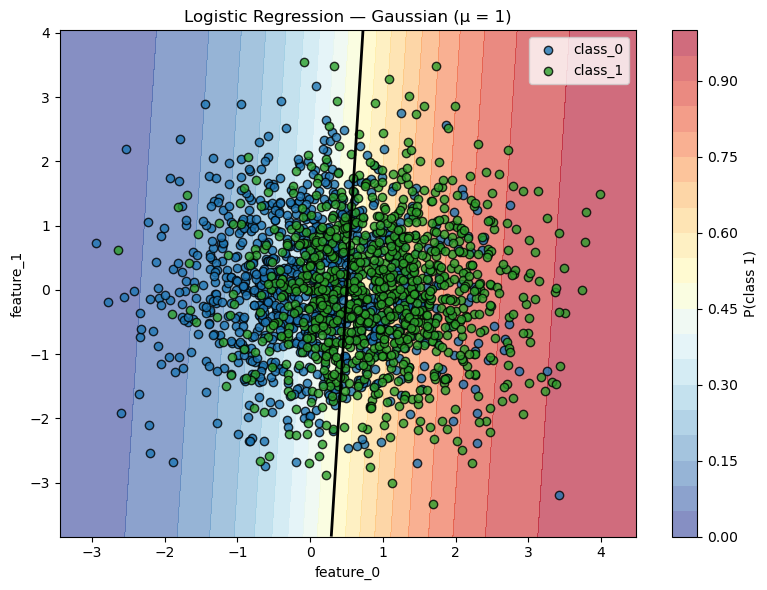

For μ = 1
[[704 296]
 [318 682]]
False Positive rate 0.148
False Negative rate 0.159
Accuracy = 69.30%


In [83]:
#μ = 1

mean4 = [1,0]
N_value = 1000
x_values5, y_values5 = np.random.multivariate_normal(mean1, covariance, N_value).T
x_values6, y_values6 = np.random.multivariate_normal(mean4, covariance, N_value).T

classarray2 = np.concatenate( (np.zeros(len(x_values5)), np.ones(len(x_values6)))).astype(int)
datalist2 = []
for i in np.arange(len(x_values5)):
    datalist2.append(np.array([x_values5[i],y_values5[i]]))

for j in np.arange(len(x_values6)):
    datalist2.append(np.array([x_values6[j],y_values6[j]]))
    
dataarray2 = np.array(datalist2)
#Get test data. I took a fifth of the data to be my test data.
test_data2 = dataarray2
test_class2 = classarray2
#Fit test data.
clf_lr2 = LogisticRegression()
clf_lr2.fit(test_data2, test_class2)

#print(f"Weights w = {clf_lr.coef_[0]}")
#print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
#print(f"Accuracy = {clf_lr1.score(test_data1, test_class1):.2%}")

my_dataset2 = Bunch(
    data=test_data2,
    target=test_class2,
    target_names=np.array(['class_0','class_1']),
    feature_names=['feature_0','feature_1'],
    DESCR="2D Gaussian dataset"
    )

plot_decision_boundary(
    clf_lr2, test_data2, test_class2,
    title='Logistic Regression — Gaussian (μ = 1)',
    feature_names= my_dataset2.feature_names[:2],
    class_names=list(my_dataset2.target_names[:2])
    )
plt.tight_layout()
plt.show()

class_pred2 = clf_lr2.predict(test_data2)
cm2 = confusion_matrix(test_class2, class_pred2)
print('For μ = 1')
print(cm2)
print('False Positive rate',cm2[0,1]/np.sum(cm2))
print('False Negative rate',cm2[1,0]/np.sum(cm2))
print(f"Accuracy = {clf_lr2.score(test_data2, test_class2):.2%}")
accuracy_array[2] = clf_lr2.score(test_data2, test_class2)

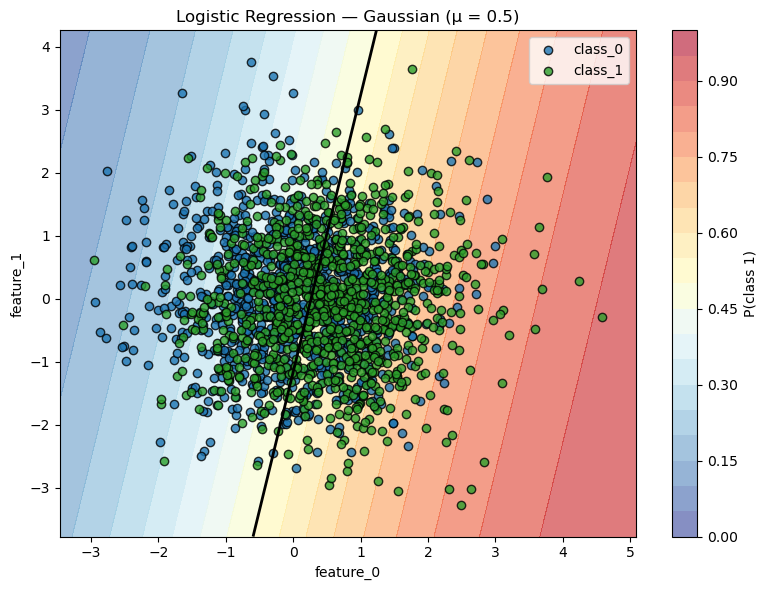

For μ = 0.5
[[592 408]
 [387 613]]
False Positive rate 0.204
False Negative rate 0.1935
Accuracy = 60.25%


In [85]:
#μ = 0.5

mean5 = [0.5,0]
N_value = 1000
x_values7, y_values7 = np.random.multivariate_normal(mean1, covariance, N_value).T
x_values8, y_values8 = np.random.multivariate_normal(mean5, covariance, N_value).T

classarray3 = np.concatenate( (np.zeros(len(x_values7)), np.ones(len(x_values8)))).astype(int)
datalist3 = []
for i in np.arange(len(x_values7)):
    datalist3.append(np.array([x_values7[i],y_values7[i]]))

for j in np.arange(len(x_values8)):
    datalist3.append(np.array([x_values8[j],y_values8[j]]))
    
dataarray3 = np.array(datalist3)
#Get test data. I took a fifth of the data to be my test data.
test_data3 = dataarray3
test_class3 = classarray3
#Fit test data.
clf_lr3 = LogisticRegression()
clf_lr3.fit(test_data3, test_class3)

#print(f"Weights w = {clf_lr.coef_[0]}")
#print(f"Bias    b = {clf_lr.intercept_[0]:.3f}")
#print(f"Accuracy = {clf_lr1.score(test_data1, test_class1):.2%}")

my_dataset3 = Bunch(
    data=test_data3,
    target=test_class3,
    target_names=np.array(['class_0','class_1']),
    feature_names=['feature_0','feature_1'],
    DESCR="2D Gaussian dataset"
    )

plot_decision_boundary(
    clf_lr3, test_data3, test_class3,
    title='Logistic Regression — Gaussian (μ = 0.5)',
    feature_names= my_dataset3.feature_names[:2],
    class_names=list(my_dataset3.target_names[:2])
    )
plt.tight_layout()
plt.show()

class_pred3 = clf_lr3.predict(test_data3)
cm3 = confusion_matrix(test_class3, class_pred3)
print('For μ = 0.5')
print(cm3)
print('False Positive rate',cm3[0,1]/np.sum(cm3))
print('False Negative rate',cm3[1,0]/np.sum(cm3))
print(f"Accuracy = {clf_lr3.score(test_data3, test_class3):.2%}")
accuracy_array[3] = clf_lr3.score(test_data3, test_class3)

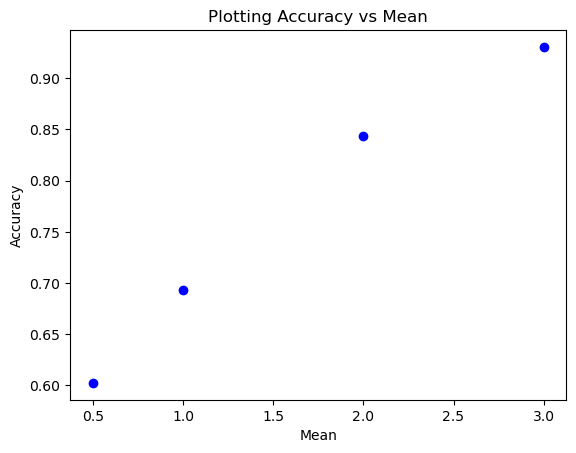

In [87]:
fig, ax = plt.subplots()

plt.scatter(mean_array, accuracy_array, c='b')
plt.title('Plotting Accuracy vs Mean')
plt.xlabel('Mean')
plt.ylabel('Accuracy')

plt.show()

Question 4 for the Homework 4

1. Why does performance degrade as μ -> 0?
    The accuracy decreases as the mean decreases because the centers of the two distributions are getting closer and closer. This means that given their covariances are the same, the two distributions are overlapping each other more and more. Thus it becomes harder and harder to separate the two data sets without more and more false classifications.

2. Does adding more data help when μ = 0?
    Adding more data could not help when the mean of the two distributions are the same. Given that covariances are already the same, there is simply no differences between the two data sets. They are the same distribution, so there's no way you can use a linear classifier to accurately separated them. It won't matter if you increase the number of points of the data, because this fact about the two distributions won't change. 


3. What assumption does a linear classifier make about the data?
    The key assumption made by a linear classifier is that it assumes the best method of separating two classes is drawing a straight line through the data. This doesn't take into account situations where a curved line, some kind of shape, etc... might be a better fit for the data. 
